In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

In [25]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

C:\Users\victo\AppData\Local\Temp\ipykernel_7620\4168379563.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)


matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


In [29]:
data = data.drop(data[data["position"] == "team"].index) 

In [28]:
#dropping columns drops international event data as it has a lot of missing data, but we do not need that data for this, so do not drop data
"""
from utils.transform import smart_drop_na
# drop columns with more than a given percentage of missing values
data = smart_drop_na(
    data,
    column_percentage_threshold=0.20,
    row_percentage_threshold=0
)
"""

'\nfrom utils.transform import smart_drop_na\n# drop columns with more than a given percentage of missing values\ndata = smart_drop_na(\n    data,\n    column_percentage_threshold=0.20,\n    row_percentage_threshold=0\n)\n'

In [30]:
uniq_player_ids = data["playerid"].unique()
playerid_to_adj_index = dict(zip(uniq_player_ids, range(len(uniq_player_ids))))
adj_matrix = np.zeros((len(uniq_player_ids), len(uniq_player_ids)))

In [31]:
for i in tqdm(range(0, len(data), 10)):
    player_ids = []
    for j in range(10):
        player_ids.append(data.iloc[i + j]["playerid"])
    
    for p1 in player_ids:
        for p2 in player_ids:
            adj_matrix[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] = 1

  0%|          | 0/10053 [00:00<?, ?it/s]

In [83]:
for j in range(adj_matrix.shape[0]):
    adj_matrix[j,j] = 0

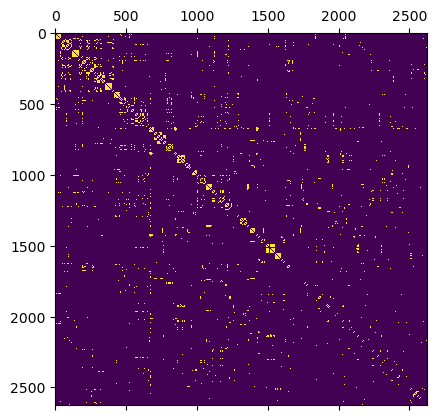

In [84]:
plt.matshow(adj_matrix)

In [85]:
z = sklearn.cluster.spectral_clustering(adj_matrix, n_clusters=5)

In [47]:
league_to_region_dict = {"LFL2":"EU", 
"LPL": "CN", 
"LCKC": "KR", 
"LVP SL": "EU", 
"LCK" : "KR", 
"NLC": "EU", 
"LCP": "APAC",
"LEC": "EU",
"HLL": "EU",
"PRM": "EU", 
"LFL": "EU",
"LIT": "EU",
"TCL": "EU",
"HW": "EU",
"LJL": "JP",
"LTA S": "LAT",
"LTA N": "NA",
"RL": "EU",
"NEXO": "EU", 
"CD": "LAT",
"EBL": "EU",
"PCS": "APAC", 
"ROL": "EU",
"LPLOL": "EU", 
"AL": "EU",
"LTA": "NA",
"VCS": "APAC",
"FST": "INT",
"EM": "EU",
"LRS": "LAT",
"LRN": "LAT",
"NACL": "NA", 
"LAS": "KR",
"HC": "EU", 
"PRMP": "EU",
"HM": "EU", 
"CT": "EU",
"Asia Master": "INT",
"MSI": "INT",
"EWC": "INT",
"WLDs": "INT",
"ASI": "INT",
"IC": "EU",
"KeSPA": "KR",
"DCup": "CN"
}

In [53]:
regions = dict.fromkeys(set(league_to_region_dict.values()), 0)
regions

{'APAC': 0, 'CN': 0, 'LAT': 0, 'NA': 0, 'EU': 0, 'INT': 0, 'JP': 0, 'KR': 0}

In [86]:
for i in range(5):
    region_count = dict.fromkeys(set(league_to_region_dict.values()), 0)
    for playerid in uniq_player_ids[z == i]:
        leagues = data[data["playerid"] == playerid]["league"].unique()
        for league in leagues:
            region = league_to_region_dict[league]
            region_count[region] += 1
    print(i)
    print(region_count)
    print("__")


0
{'APAC': 3, 'CN': 0, 'LAT': 2, 'NA': 3, 'EU': 2049, 'INT': 0, 'JP': 0, 'KR': 0}
__
1
{'APAC': 251, 'CN': 175, 'LAT': 37, 'NA': 93, 'EU': 56, 'INT': 470, 'JP': 82, 'KR': 298}
__
2
{'APAC': 0, 'CN': 0, 'LAT': 224, 'NA': 4, 'EU': 0, 'INT': 0, 'JP': 0, 'KR': 0}
__
3
{'APAC': 0, 'CN': 0, 'LAT': 108, 'NA': 124, 'EU': 1, 'INT': 0, 'JP': 0, 'KR': 0}
__
4
{'APAC': 0, 'CN': 0, 'LAT': 0, 'NA': 0, 'EU': 216, 'INT': 0, 'JP': 0, 'KR': 0}
__


In [94]:
z

array([0, 0, 0, ..., 1, 1, 1], shape=(2626,), dtype=int32)

In [104]:
colors = ["#f9c80e", "#f86624", "#ea3546", "#662e9b", "#43bccd"]

color_labels = [colors[x] for x in z]



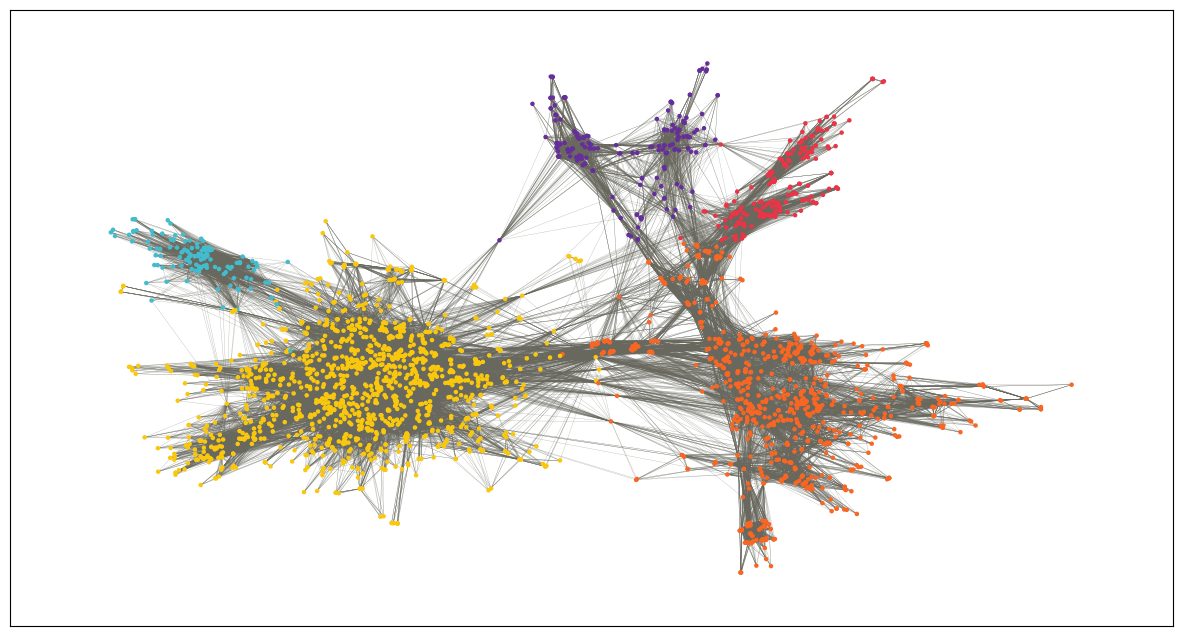

In [106]:
import networkx as nx
plt.figure(figsize=(15,8))
G = nx.from_numpy_array(adj_matrix)
layout = nx.spring_layout(G, seed=1)
nx.draw_networkx_nodes(G, layout, node_size=5, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")

In [112]:
layout

{0: array([-0.30835816, -0.03894429]),
 1: array([-0.33765534, -0.04772471]),
 2: array([-0.30940911, -0.03692764]),
 3: array([-0.29546019,  0.01593183]),
 4: array([-0.30915135, -0.03713127]),
 5: array([-0.31680799, -0.04314511]),
 6: array([-0.31367764, -0.05434731]),
 7: array([-0.31679291, -0.04335828]),
 8: array([-0.3133989 , -0.05567537]),
 9: array([-0.31483275, -0.04980247]),
 10: array([-0.26943007, -0.05781086]),
 11: array([-0.29191676, -0.04576922]),
 12: array([-0.28790006, -0.03913125]),
 13: array([-0.23197086, -0.05081223]),
 14: array([-0.32304344, -0.04437429]),
 15: array([-0.3274487 ,  0.00340934]),
 16: array([-0.40940174,  0.02090042]),
 17: array([-0.28217623, -0.11097571]),
 18: array([-0.27631834, -0.04227928]),
 19: array([-0.34555572, -0.11106892]),
 20: array([-0.32942581, -0.03048269]),
 21: array([-0.32542449, -0.04685305]),
 22: array([-0.32520625, -0.04768612]),
 23: array([-0.32829365, -0.03132718]),
 24: array([-0.26632041, -0.04955677]),
 25: array

In [113]:
G = nx.from_numpy_array(adj_matrix)

In [114]:
G.edges()

EdgeView([(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18), (0, 19), (0, 20), (0, 21), (0, 22), (0, 23), (0, 24), (0, 25), (0, 26), (0, 27), (0, 28), (0, 29), (0, 30), (0, 31), (0, 32), (0, 33), (0, 34), (0, 35), (0, 36), (0, 37), (0, 38), (0, 39), (0, 145), (0, 340), (0, 503), (0, 524), (0, 525), (0, 527), (0, 530), (0, 577), (0, 819), (0, 986), (0, 989), (0, 1003), (0, 1007), (0, 1028), (0, 1149), (0, 1207), (0, 1273), (0, 1832), (0, 1837), (0, 1838), (0, 1839), (0, 1872), (0, 1906), (0, 2019), (0, 2046), (0, 2050), (0, 2308), (0, 2309), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20), (1, 21), (1, 22), (1, 23), (1, 24), (1, 25), (1, 26), (1, 27), (1, 28), (1, 29), (1, 30), (1, 31), (1, 32), (1, 33), (1, 34), (1, 35), (1, 36), (1, 37), (1, 38), (1, 39), (1, 145), (1, 266

In [ ]:
# modified from https://plotly.com/python/network-graphs/
import plotly.graph_objects as go
G = nx.random_geometric_graph(200, 0.125)

edge_x = []
edge_y = []
for edge in G